# Exploratory Data Analysis (EDA)

This notebook performs an exploratory analysis of the garment worker
productivity dataset, focusing on data quality, variable distributions,
and relationships with the target variable.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_excel("Dataset_Productivity.xlsx")

# Basic cleaning and overview
dataset['wip'] = dataset['wip'].fillna(0)
dataset['Dipartimento'] = dataset['Dipartimento'].str.strip().str.lower()

dataset.shape
dataset.info()
dataset.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Dipartimento          1197 non-null   object 
 1   Team                  1197 non-null   int64  
 2   Quarto                1197 non-null   object 
 3   Giorno                1197 non-null   object 
 4   DELTA                 1197 non-null   float64
 5   smv                   1197 non-null   float64
 6   wip                   1197 non-null   int64  
 7   MediaOreStraordinari  1197 non-null   float64
 8   Incentivi             1197 non-null   int64  
 9   CambioMansione        1197 non-null   int64  
 10  NumeroLavoratori      1197 non-null   float64
dtypes: float64(4), int64(4), object(3)
memory usage: 103.0+ KB


,Dipartimento,Team,Quarto,Giorno,DELTA,smv,wip,MediaOreStraordinari,Incentivi,CambioMansione,NumeroLavoratori
0,sweing,1,Quarter3,Sunday,-0.396758,49.10,1381,3.0,24,0,57.5
1,sweing,1,Quarter4,Tuesday,-0.331786,22.53,708,2.0,0,1,42.0
2,finishing,1,Quarter1,Monday,-0.245404,3.94,0,2.0,0,0,19.0
3,finishing,1,Quarter2,Wednesday,-0.181639,3.94,0,2.0,0,0,12.0
4,finishing,1,Quarter1,Sunday,-0.151278,3.94,0,7.0,0,0,8.0


## Target variable: DELTA

DELTA represents the difference between expected and actual productivity.
We analyze its distribution and presence of outliers.

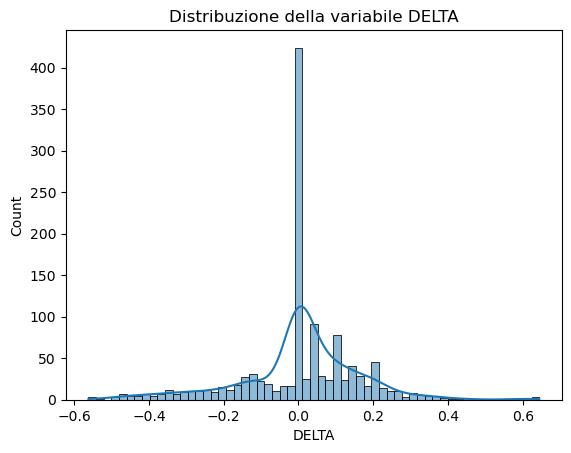

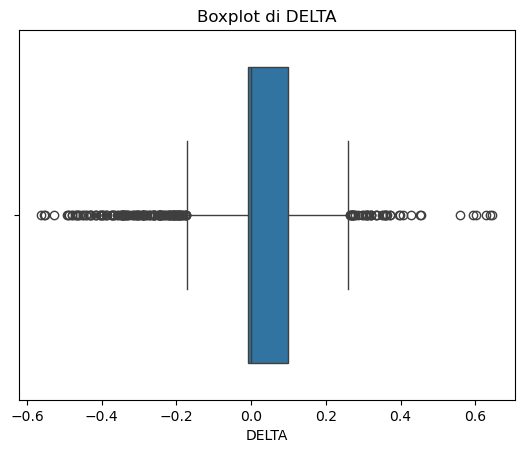

In [3]:
sns.histplot(dataset['DELTA'], kde=True)
plt.title("Distribuzione della variabile DELTA")
plt.show()

sns.boxplot(x=dataset['DELTA'])
plt.title("Boxplot di DELTA")
plt.show()

In [4]:
print(f"Curtosi: {dataset['DELTA'].kurt()}")
print(f"Asimmetria: {dataset['DELTA'].skew()}")

Q1 = dataset['DELTA'].quantile(0.25)
Q3 = dataset['DELTA'].quantile(0.75)
IQR = Q3 - Q1

limite_inferiore = Q1 - 1.5 * IQR
limite_superiore = Q3 + 1.5 * IQR

print(f"Limite inferiore: {limite_inferiore:.3f}")
print(f"Limite superiore: {limite_superiore:.3f}")

Curtosi: 2.0030018034935204
Asimmetria: -0.43160676643897894
Limite inferiore: -0.173
Limite superiore: 0.262


## Discretization of DELTA
DELTA is discretized into three classes based on Tukey's rule:
- Overestimation
- Realistic estimation
- Underestimation

In [5]:
def classify_delta(delta):
    if delta < limite_inferiore:
        return 'Sovrastima'
    elif delta > limite_superiore:
        return 'Sottostima'
    else:
        return 'Stima realistica'

dataset['Delta_class'] = dataset['DELTA'].apply(classify_delta)
dataset['Delta_class'].value_counts(normalize=True)

Delta_class
Stima realistica    0.843776
Sovrastima          0.116959
Sottostima          0.039265
Name: proportion, dtype: float64

## Categorical variables
We inspect the distribution of main categorical variables.


Distribuzione di Dipartimento:

Dipartimento
sweing       691
finishing    506
Name: count, dtype: int64

Distribuzione di Quarto:

Quarto
Quarter1    360
Quarter2    335
Quarter4    248
Quarter3    210
Quarter5     44
Name: count, dtype: int64

Distribuzione di Giorno:

Giorno
Wednesday    208
Sunday       203
Tuesday      201
Monday       199
Thursday     199
Saturday     187
Name: count, dtype: int64


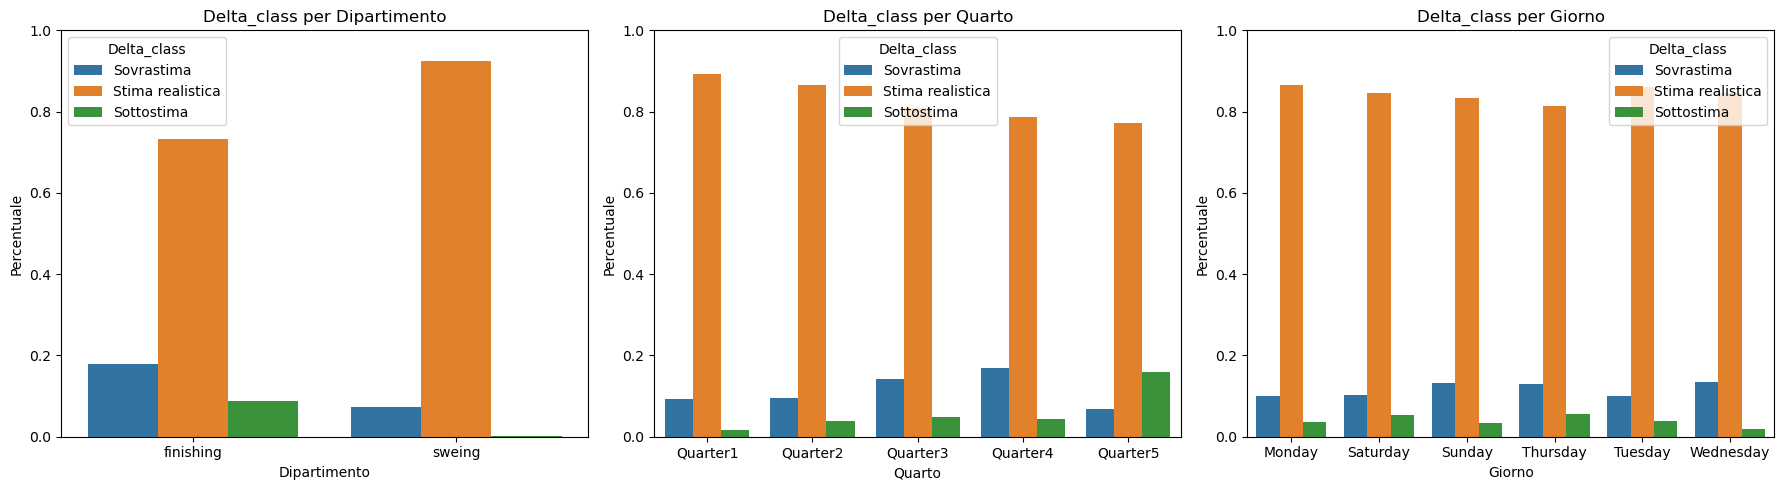

In [6]:
cat_vars = ['Dipartimento', 'Quarto', 'Giorno']

for var in cat_vars:
    print(f"\nDistribuzione di {var}:\n")
    print(dataset[var].value_counts())

ordine_classi = ['Sovrastima', 'Stima realistica', 'Sottostima']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(cat_vars):
    prop_df = (
        dataset.groupby([var, 'Delta_class'])
        .size()
        .div(dataset.groupby(var).size())
        .reset_index(name='Percentuale')
    )
    
    prop_df['Delta_class'] = pd.Categorical(
        prop_df['Delta_class'],
        categories=ordine_classi,
        ordered=True
    )
    
    sns.barplot(
        data=prop_df,
        x=var,
        y='Percentuale',
        hue='Delta_class',
        ax=axes[i]
    )
    
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'Delta_class per {var}')

plt.tight_layout()
plt.show()

## Numerical variables
We analyze distributions, outliers, and correlations among numerical features.

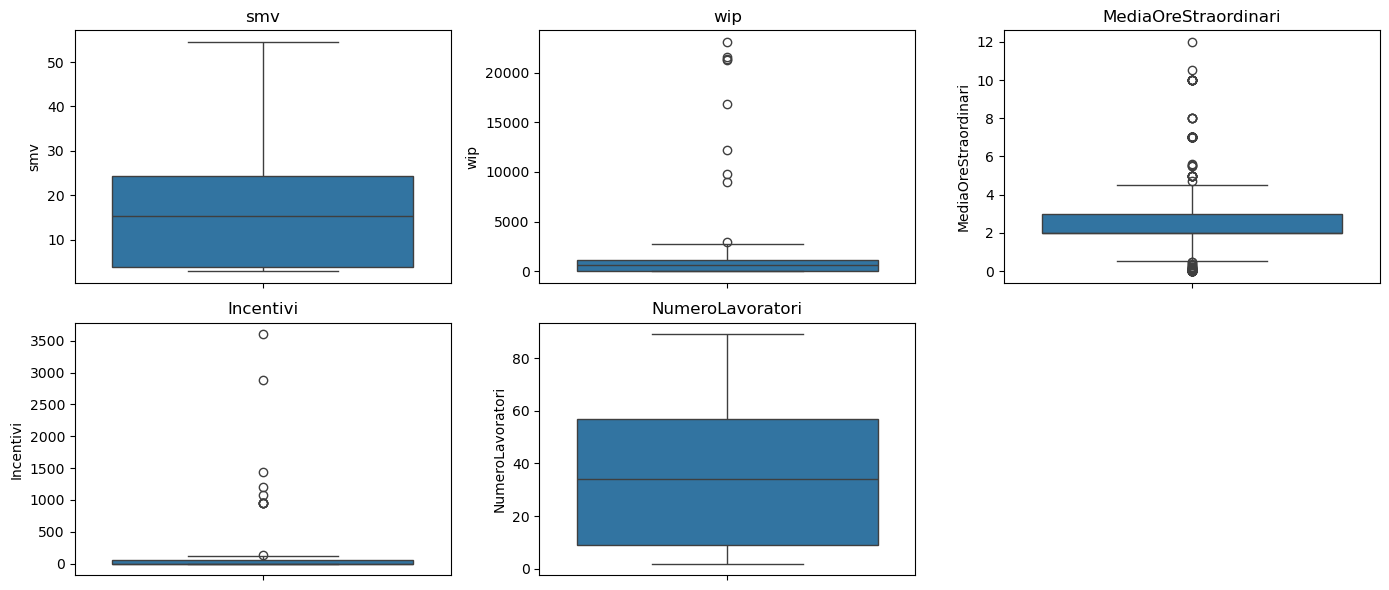

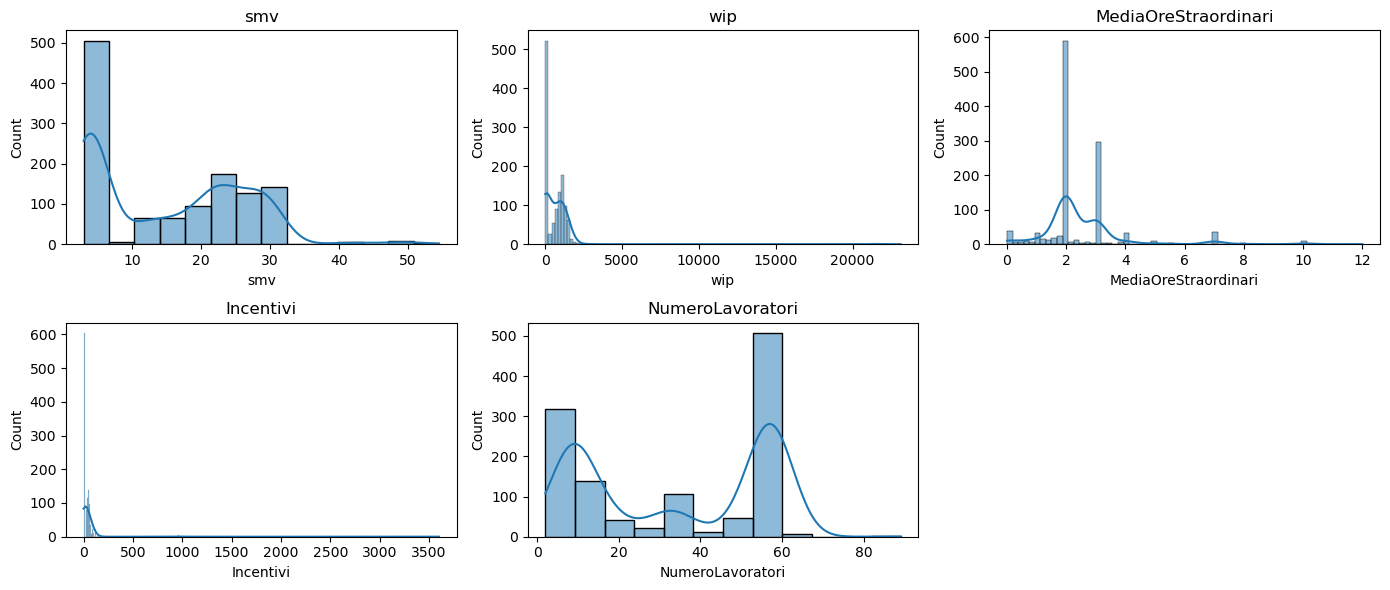

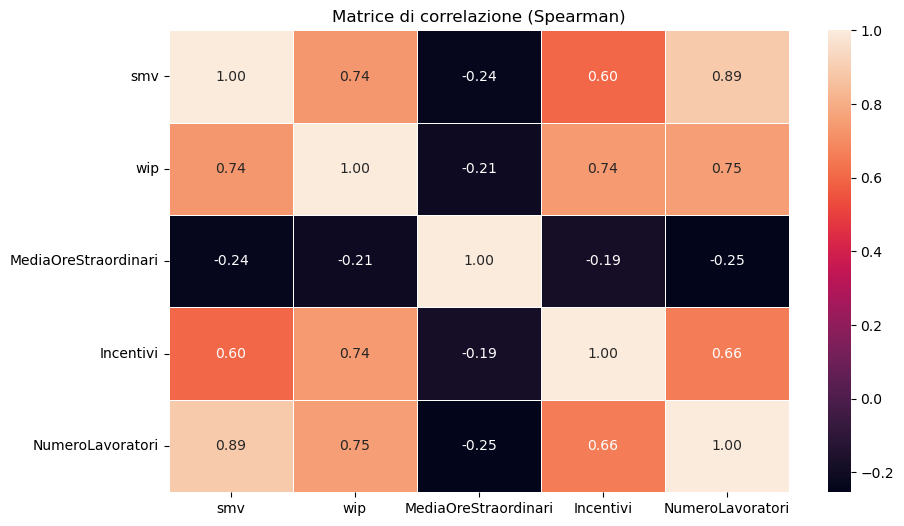

In [7]:
num_vars = ['smv', 'wip', 'MediaOreStraordinari', 'Incentivi', 'NumeroLavoratori']
dataset[num_vars].describe()

plt.figure(figsize=(14, 6))
for i, var in enumerate(num_vars):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=dataset[var])
    plt.title(var)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
for i, var in enumerate(num_vars):
    plt.subplot(2, 3, i+1)
    sns.histplot(dataset[var], kde=True)
    plt.title(var)
plt.tight_layout()
plt.show()


corr_matrix = dataset[num_vars].corr(method='spearman')

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Matrice di correlazione (Spearman)")
plt.show()

## Key observations

- The target variable shows asymmetry and the presence of outliers
- Several numerical variables present skewed distributions
- Categorical variables show different productivity patterns
- Relationships appear non-linear, motivating the use of flexible models